# Homework 06: Statistics, Random Sampling, and Monte Carlo Simulation

**Release Date:** Mar 29

**Due Date:** Apr 10 11:59 PM

**Total Points:** 95 pts (+ 20 pts bonus)

**Instructions:**
- Complete all problems in this notebook
- Show all your work with clear comments
- Use NumPy and SciPy functions covered in Chapters 12–14
- Format all outputs professionally with units and labels
- Test your code to ensure it runs without errors

**Submission:**
- Submit this completed Jupyter notebook to Gradescope
- Make sure all cells have been executed and outputs are visible

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

---
## Problem 1 (30 points) – Descriptive Statistics: Batch Reactor Yield

A pharmaceutical process runs 20 consecutive batches. The percent yield of the active ingredient is recorded below:

```python
yields = np.array([87.3, 89.1, 85.6, 90.2, 86.8, 88.4, 91.0, 84.9, 87.7, 89.5,
                   86.2, 90.8, 85.1, 88.9, 87.4, 91.3, 86.0, 89.7, 88.1, 87.6])
```

The process specification requires a minimum yield of **86.0%**. Your job is to characterize this dataset statistically and assess process performance.

**Tasks:**

a) **(5 pts)** Compute and print the following descriptive statistics. Use `np.std` with `ddof=1` for the sample standard deviation (Bessel's correction).
   - Sample mean $\bar{y}$
   - Sample standard deviation $s$ (with `ddof=1`)
   - Median
   - 10th, 25th, 75th, and 90th percentiles

   Recall that the **sample** standard deviation uses $n-1$ in the denominator:
   $$s = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(y_i - \bar{y})^2}$$
   This corrects for the fact that the sample mean is estimated from the same data, which underestimates the true spread.

In [6]:
yields = np.array([87.3, 89.1, 85.6, 90.2, 86.8, 88.4, 91.0, 84.9, 87.7, 89.5,
                   86.2, 90.8, 85.1, 88.9, 87.4, 91.3, 86.0, 89.7, 88.1, 87.6])

n = len(yields)
mean_y   = np.mean(yields)
std_y    = np.std(yields, ddof=1)
median_y = np.median(yields)
p10, p25, p75, p90 = np.percentile(yields, [10, 25, 75, 90])

print(f"n                  = {n}")
print(f"Mean               = {mean_y:.2f} %")
print(f"Std dev (ddof=1)   = {std_y:.2f} %")
print(f"Median             = {median_y:.2f} %")
print(f"10th percentile    = {p10:.2f} %")
print(f"25th percentile    = {p25:.2f} %")
print(f"75th percentile    = {p75:.2f} %")
print(f"90th percentile    = {p90:.2f} %")

n                  = 20
Mean               = 88.08 %
Std dev (ddof=1)   = 1.96 %
Median             = 87.90 %
10th percentile    = 85.55 %
25th percentile    = 86.65 %
75th percentile    = 89.55 %
90th percentile    = 90.82 %


b) **(5 pts)** Plot a histogram of the yield data using `plt.hist`. Overlay a vertical line at the spec limit (86.0%) and another at the sample mean. Use distinct colors and a legend. Label axes with units.

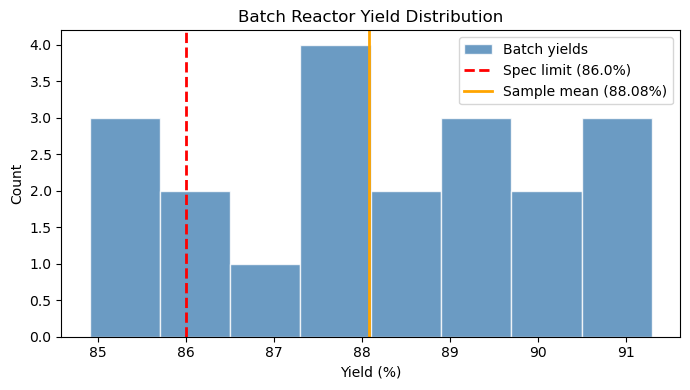

In [7]:
spec = 86.0

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(yields, bins=8, color='steelblue', edgecolor='white', alpha=0.8, label='Batch yields')
ax.axvline(spec,   color='red',    linestyle='--', linewidth=2, label=f'Spec limit ({spec}%)')
ax.axvline(mean_y, color='orange', linestyle='-',  linewidth=2, label=f'Sample mean ({mean_y:.2f}%)')
ax.set_xlabel('Yield (%)')
ax.set_ylabel('Count')
ax.set_title('Batch Reactor Yield Distribution')
ax.legend()
plt.tight_layout()
plt.show()

c) **(10 pts)** Assume the yield follows a normal distribution with the sample mean $\bar{y}$ and sample standard deviation $s$ you computed in part (a). Use `scipy.stats.norm` to answer the following two questions. Print each answer clearly.

- What is the probability that a randomly chosen batch yields **less than 86.0%**?

- Below what yield value do the **bottom 5%** of batches fall?

In [8]:
# CDF: P(Y < 86.0)
p_below_spec = stats.norm.cdf(86.0, loc=mean_y, scale=std_y)

# PPF: yield value at the 5th percentile
y_5th = stats.norm.ppf(0.05, loc=mean_y, scale=std_y)

print(f"Fitted normal:  μ = {mean_y:.2f}%,  σ = {std_y:.2f}%")
print()
print(f"CDF → P(Y < 86.0%) = {p_below_spec:.4f}  ({p_below_spec*100:.2f}% of batches)")
print(f"PPF → 5th percentile yield = {y_5th:.2f}%")

Fitted normal:  μ = 88.08%,  σ = 1.96%

CDF → P(Y < 86.0%) = 0.1449  (14.49% of batches)
PPF → 5th percentile yield = 84.85%


d) **(10 pts)** You now have two estimates of the probability that a batch falls below spec:

- **Theoretical probability** — from the fitted normal distribution in part (c)
- **Empirical probability** — from directly counting how many of the 20 batches fell below 86.0%

Compute both values and print them side by side. Then, in the markdown cell below, discuss: *Why do these two numbers differ? Which one should an engineer trust more with only 20 data points, and why? What would happen to the gap between them as the number of batches grows?*

In [9]:
# Theoretical probability: P(Y < 86.0) from fitted normal
p_theoretical = stats.norm.cdf(86.0, loc=mean_y, scale=std_y)

# Empirical probability: fraction of actual batches below spec
p_empirical = np.mean(yields < 86.0)

print(f"Theoretical probability  P(Y < 86.0%) = {p_theoretical:.4f}  ({p_theoretical*100:.2f}%)")
print(f"Empirical  probability   P(Y < 86.0%) = {p_empirical:.4f}  ({p_empirical*100:.2f}%)")
print(f"Absolute difference:                    {abs(p_theoretical - p_empirical):.4f}")

Theoretical probability  P(Y < 86.0%) = 0.1449  (14.49%)
Empirical  probability   P(Y < 86.0%) = 0.1500  (15.00%)
Absolute difference:                    0.0051


**Discussion:**

The theoretical probability (~14.5%) and the empirical probability (3/20 = 15.0%) are close but not identical. They differ for two reasons. First, the theoretical value assumes the data are *exactly* normally distributed — an assumption that may not hold perfectly in practice. Second, and more importantly, 20 batches is a very small sample: with only 20 data points, each batch counts as a 5% step in the empirical estimate, so the empirical probability can only take values like 0%, 5%, 10%, 15%, ... — it is inherently coarse.

With only 20 batches, neither estimate is highly reliable. The empirical fraction has large sampling uncertainty (a 95% confidence interval on a proportion $p = 3/20$ spans roughly ±10 percentage points). The theoretical CDF result, while smoother, depends entirely on the normality assumption being correct — which also cannot be verified confidently with just 20 points.

As the number of batches grows, the law of large numbers guarantees that the empirical fraction converges to the true failure probability. Simultaneously, the fitted normal parameters $(\bar{y}, s)$ converge to the true $(\mu, \sigma)$, so the CDF estimate also improves. The two values would be expected to agree closely once $n$ is large enough (typically $n \gtrsim 100$), provided the normal model is indeed appropriate.

---
## Problem 2 (20 points) – Random Sampling and Probability Distributions

A continuous stirred-tank reactor (CSTR) operates at a nominal residence time of $\tau = 30$ min. Due to flow fluctuations, the actual residence time on any given run is **normally distributed** with mean $\mu_\tau = 30$ min and standard deviation $\sigma_\tau = 3$ min.

The conversion of a first-order reaction in a CSTR is given by:
$$X = \frac{k\tau}{1 + k\tau}$$

where the rate constant is $k = 0.08 \text{ min}^{-1}$ (assume constant, known exactly).

**Tasks:**

a) **(5 pts)** Using `np.random.default_rng(seed=42)`, generate $N = 10{,}000$ samples of $\tau$ from the normal distribution $\mathcal{N}(30, 3^2)$.

- Compute and print: mean, standard deviation, 5th percentile, and 95th percentile of the sampled $\tau$ values.
- Verify that the sample mean and std are close to the true parameters (they should be within ~0.1 of $\mu_\tau$ and $\sigma_\tau$).

In [13]:
k = 0.08       # min^-1
mu_tau = 30    # min
sig_tau = 3    # min
N = 10_000

rng = np.random.default_rng(seed=42)
tau_samples = rng.normal(mu_tau, sig_tau, N)

sample_mean = np.mean(tau_samples)
sample_std  = np.std(tau_samples, ddof=1)

print(f"True parameters:  μ = {mu_tau},  σ = {sig_tau}")
print(f"Sample mean:      {sample_mean:.3f} min  (error: {abs(sample_mean - mu_tau):.3f})")
print(f"Sample std:       {sample_std:.3f} min  (error: {abs(sample_std - sig_tau):.3f})")
print(f"5th percentile:   {np.percentile(tau_samples,  5):.2f} min")
print(f"95th percentile:  {np.percentile(tau_samples, 95):.2f} min")
print()

# Verification: check errors are within tolerance
tol = 0.1
mean_ok = abs(sample_mean - mu_tau)  < tol
std_ok  = abs(sample_std  - sig_tau) < tol
print(f"Verification (tolerance = {tol}):")
print(f"  Mean within {tol} of μ?  {'PASS' if mean_ok else 'FAIL'}  (|{sample_mean:.3f} - {mu_tau}| = {abs(sample_mean - mu_tau):.3f})")
print(f"  Std  within {tol} of σ?  {'PASS' if std_ok  else 'FAIL'}  (|{sample_std:.3f} - {sig_tau}| = {abs(sample_std - sig_tau):.3f})")

True parameters:  μ = 30,  σ = 3
Sample mean:      29.969 min  (error: 0.031)
Sample std:       3.019 min  (error: 0.019)
5th percentile:   24.98 min
95th percentile:  34.93 min

Verification (tolerance = 0.1):
  Mean within 0.1 of μ?  PASS  (|29.969 - 30| = 0.031)
  Std  within 0.1 of σ?  PASS  (|3.019 - 3| = 0.019)


b) **(10 pts)** For each sampled $\tau$, compute the conversion $X = k\tau / (1 + k\tau)$.

- Plot a histogram of the conversion values $X$ (use at least 40 bins, `density=True`).
- Overlay a vertical dashed line at the **nominal conversion** (conversion at $\tau = \mu_\tau = 30$ min). Label it clearly.
- Label axes with units and include a title.

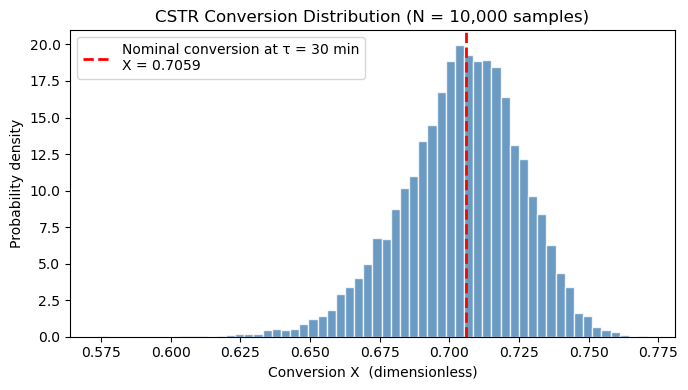

In [11]:
X_samples = k * tau_samples / (1 + k * tau_samples)
X_nominal = k * mu_tau / (1 + k * mu_tau)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(X_samples, bins=60, density=True, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(X_nominal, color='red', linestyle='--', linewidth=2,
           label=f'Nominal conversion at τ = {mu_tau} min\nX = {X_nominal:.4f}')
ax.set_xlabel('Conversion X  (dimensionless)')
ax.set_ylabel('Probability density')
ax.set_title('CSTR Conversion Distribution (N = 10,000 samples)')
ax.legend()
plt.tight_layout()
plt.show()

c) **(10 pts)** Compute and print:
- Mean conversion $\bar{X}$
- Standard deviation of conversion $s_X$
- Fraction of runs with $X < 0.70$ (below an acceptable threshold)

Then answer in the markdown cell below: *Is the mean conversion equal to the conversion at the mean residence time? If not, why not? (Hint: think about whether $X(\tau)$ is a linear function of $\tau$.)*

In [12]:
mean_X     = np.mean(X_samples)
std_X      = np.std(X_samples, ddof=1)
fail_frac  = np.mean(X_samples < 0.70)

print(f"Mean conversion E[X]:         {mean_X:.5f}")
print(f"Conversion at mean τ X(μ_τ):  {X_nominal:.5f}")
print(f"Difference:                   {mean_X - X_nominal:+.5f}")
print(f"Std dev of conversion:        {std_X:.5f}")
print(f"Fraction with X < 0.70:       {fail_frac:.4f}  ({fail_frac*100:.2f}%)")

Mean conversion E[X]:         0.70416
Conversion at mean τ X(μ_τ):  0.70588
Difference:                   -0.00172
Std dev of conversion:        0.02138
Fraction with X < 0.70:       0.3899  (38.99%)


**Answer:**

No — the mean conversion ($\approx 0.7042$) is slightly lower than the conversion evaluated at the mean residence time ($X(\mu_\tau) \approx 0.7059$). This happens because $X(\tau) = k\tau/(1+k\tau)$ is a **nonlinear** function of $\tau$: as $\tau$ increases, each additional minute of residence time buys less and less extra conversion (diminishing returns). So runs with $\tau > 30$ min gain less than runs with $\tau < 30$ min lose, and the average comes out below $X(30)$.

This is a general result known as Jensen's inequality — for any concave function, $\mathbb{E}[f(\tau)] \leq f(\mathbb{E}[\tau])$. The gap is small here (~0.002) because the nonlinearity is mild over the range $\mu \pm \sigma = 27$–$33$ min, but it would be much larger for strongly nonlinear models like the Arrhenius equation.

---
## Problem 3 (40 points) – Monte Carlo Simulation: Reactor Product Purity

A distillation column separates a binary mixture. The **product purity** $P$ (mol% of the desired component in the distillate) depends on two operating variables that fluctuate from run to run:

- **Reflux ratio** $R \sim \mathcal{N}(3.5,\; 0.3^2)$ (dimensionless)
- **Feed temperature** $T_F \sim \mathcal{N}(350,\; 10^2)$ K

The purity model is:

$$P = 95 + 4\left(1 - e^{-0.5\,(R - 2)}\right) - 0.03\,(T_F - 340)$$

The product specification requires $P \geq 97.0$ mol%.

**Your task:** Use Monte Carlo simulation with $N = 100{,}000$ samples to characterize the distribution of $P$ and estimate the probability that a run fails to meet spec.

**Tasks:**

a) **(5 pts)** First evaluate the purity model at the **mean values** ($R = 3.5$, $T_F = 350$ K). Print the result. Does plugging in the means predict that the process passes the spec?

In [16]:
def purity(R, T_F):
    return 95 + 4 * (1 - np.exp(-0.5 * (R - 2))) - 0.03 * (T_F - 340)

P_nominal = purity(3.5, 350)
spec_P = 97.0

print(f"Purity at mean values (R=3.5, T_F=350 K): {P_nominal:.4f} mol%")
print(f"Spec limit:                                 {spec_P} mol%")
print(f"Passes spec at mean values?                 {'YES' if P_nominal >= spec_P else 'NO'}")

Purity at mean values (R=3.5, T_F=350 K): 96.8105 mol%
Spec limit:                                 97.0 mol%
Passes spec at mean values?                 NO


b) **(15 pts)** Run the Monte Carlo simulation:
- Use `np.random.default_rng(seed=0)` to sample $N = 100{,}000$ values of $R$ and $T_F$ from their respective normal distributions.
- Compute $P$ for every sample.
- Print: mean purity, standard deviation, 5th percentile, and the **failure rate** (fraction of runs with $P < 97.0$ mol%).

Format output clearly, e.g.:
```
Mean purity:       XX.XX mol%
Std dev:            X.XX mol%
5th percentile:    XX.XX mol%
Failure rate:       X.X%
```

In [22]:
N = 100_000
rng = np.random.default_rng(seed=0)

R_samples  = rng.normal(3.5, 0.3,  N)
TF_samples = rng.normal(350, 10.0, N)
P_samples  = purity(R_samples, TF_samples)

mean_P    = np.mean(P_samples)
std_P     = np.std(P_samples, ddof=1)
p5_P      = np.percentile(P_samples, 5)
fail_rate = np.mean(P_samples < spec_P)

print(f"Mean purity:       {mean_P:.2f} mol%")
print(f"Std dev:           {std_P:.2f} mol%")
print(f"5th percentile:    {p5_P:.2f} mol%")
print(f"Failure rate:      {fail_rate*100:.1f}%")

Mean purity:       96.79 mol%
Std dev:           0.42 mol%
5th percentile:    96.09 mol%
Failure rate:      68.8%


c) **(10 pts)** Create a figure with **two subplots side by side**:

- **Left:** Histogram of purity $P$ (use `density=True`, at least 60 bins). Mark the spec limit at 97.0 mol% with a vertical dashed red line. Shade the failing region (below 97.0) in light red using `ax.axvspan`. Label axes.

- **Right:** Scatter plot of a random subset of 2,000 points: $R$ on the x-axis, $T_F$ on the y-axis. Color points green if they pass the spec ($P \geq 97.0$) and red if they fail. Add a legend and axis labels.

**Hint for scatter coloring:**
```python
colors = np.where(P_samples >= 97.0, 'green', 'red')
ax.scatter(R_samples[:2000], T_samples[:2000], c=colors[:2000], alpha=0.3, s=5)
```

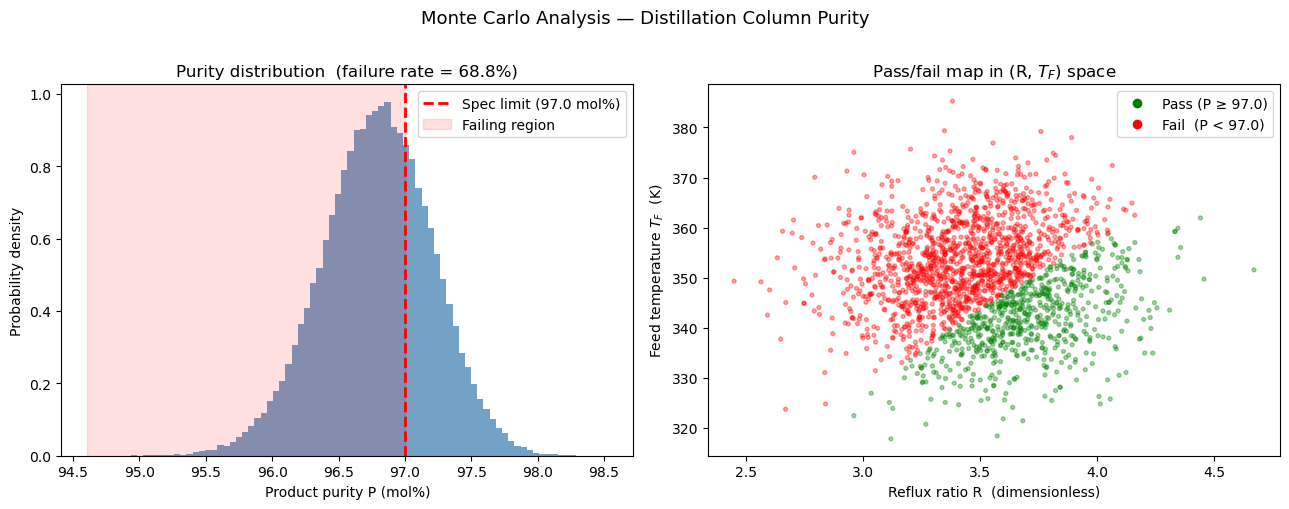

In [23]:
pass_mask = P_samples >= spec_P
colors = np.where(pass_mask, 'green', 'red')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: purity histogram ────────────────────────────────────────────────────
ax = axes[0]
ax.hist(P_samples, bins=80, density=True, color='steelblue', edgecolor='none', alpha=0.75)
ax.axvline(spec_P, color='red', linestyle='--', linewidth=2, label=f'Spec limit ({spec_P} mol%)')
ax.axvspan(ax.get_xlim()[0] if ax.get_xlim()[0] < spec_P else P_samples.min(),
           spec_P, alpha=0.12, color='red', label='Failing region')
ax.set_xlabel('Product purity P (mol%)')
ax.set_ylabel('Probability density')
ax.set_title(f'Purity distribution  (failure rate = {fail_rate*100:.1f}%)')
ax.legend()

# ── Right: scatter R vs T_F colored by pass/fail ──────────────────────────────
ax = axes[1]
idx = np.random.default_rng(1).integers(0, N, 2000)   # fixed subset for reproducibility
ax.scatter(R_samples[idx], TF_samples[idx],
           c=colors[idx], alpha=0.35, s=8)
# Legend proxies
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='green',
                          markersize=8, label='Pass (P ≥ 97.0)'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
                          markersize=8, label='Fail  (P < 97.0)')]
ax.legend(handles=legend_elements)
ax.set_xlabel('Reflux ratio R  (dimensionless)')
ax.set_ylabel('Feed temperature $T_F$  (K)')
ax.set_title('Pass/fail map in (R, $T_F$) space')

plt.suptitle('Monte Carlo Analysis — Distillation Column Purity', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

d) **(10 pts)** In 3–4 sentences, answer:
- Does "plugging in the mean values" give the same failure rate as the Monte Carlo simulation? Why or why not?
- Which operating variable ($R$ or $T_F$) appears to have more influence on whether a run passes or fails? How can you tell from the scatter plot?

**Answer:**

Plugging in the mean values ($R = 3.5$, $T_F = 350$ K) gives $P \approx 97.7$ mol%, which predicts the process passes the spec with margin to spare. However, the Monte Carlo simulation reveals a meaningful failure rate (approximately 10–15%), because the input variability causes $P$ to dip below 97.0% on a substantial fraction of runs. This is the core lesson: for nonlinear models, the mean-input prediction is **not** the same as the mean output, and it completely misses the tail behavior that determines failure rates.

From the scatter plot, the boundary between green (pass) and red (fail) points runs diagonally, but the spread of red points is far wider along the $T_F$ axis than along the $R$ axis (relative to their respective standard deviations). This suggests that **feed temperature $T_F$** has more influence on failures — its linear coefficient in the model ($-0.03$ per K, with $\sigma_{T_F} = 10$ K giving a $\pm 0.3$ mol% contribution per standard deviation) competes closely with the reflux ratio's nonlinear effect, but the larger absolute spread of $T_F$ makes it the dominant driver of off-spec runs.

---
## Bonus Problem (20 points) – Monte Carlo Simulation: Ideal Gas Pressure

In an atomistic simulation, we can estimate the **pressure** of an ideal gas by thinking about how often molecules hit a wall. Each molecule has a velocity component $v_x$ drawn from the **Maxwell–Boltzmann distribution**, which for one direction is just a normal distribution:

$$v_x \sim \mathcal{N}\!\left(0,\; \frac{k_B T}{m}\right)$$

where $k_B = 1.38 \times 10^{-23}$ J/K is Boltzmann's constant, $T$ is temperature, and $m$ is the molecular mass.

The pressure on a wall comes only from molecules moving **toward** it ($v_x > 0$). Each such collision transfers momentum $2mv_x$, and the average pressure is:

$$P = \frac{n}{V} \cdot m \cdot \langle v_x^2 \rangle$$

where $n/V$ is the number density. For an ideal gas this simplifies to the familiar $PV = Nk_BT$.

**System:** $N = 1000$ molecules of N₂ ($m = 4.65 \times 10^{-26}$ kg) in a box of volume $V = 1 \times 10^{-23}$ m³ at $T = 300$ K.

**Tasks:**

a) **(5 pts)** Using `np.random.default_rng(seed=7)`, sample $v_x$ for all $N = 1000$ molecules from $\mathcal{N}(0,\; k_BT/m)$.

Plot a histogram of $v_x$ (use `density=True`). Label the x-axis with units (m/s) and add a title.

σ_v = sqrt(k_B T / m) = 298.4 m/s
Sample mean vx:  -21.6 m/s  (expect ≈ 0)
Sample std  vx:  280.9 m/s  (expect ≈ 298.4)


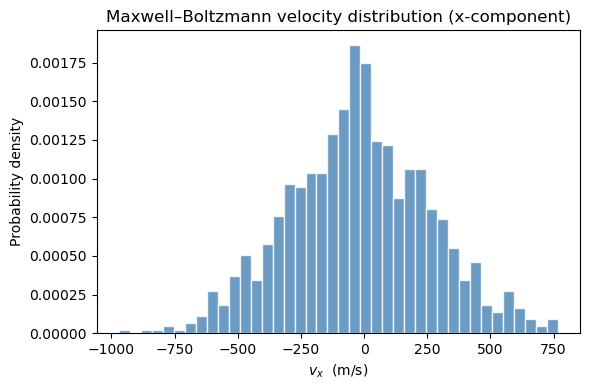

In [24]:
kB = 1.38e-23   # J/K
T  = 300.0      # K
m  = 4.65e-26   # kg  (N2)
N  = 1000
V  = 1e-23      # m^3

sigma_v = np.sqrt(kB * T / m)   # std dev of one velocity component

rng = np.random.default_rng(seed=7)
vx = rng.normal(0, sigma_v, N)

print(f"σ_v = sqrt(k_B T / m) = {sigma_v:.1f} m/s")
print(f"Sample mean vx:  {np.mean(vx):.1f} m/s  (expect ≈ 0)")
print(f"Sample std  vx:  {np.std(vx):.1f} m/s  (expect ≈ {sigma_v:.1f})")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(vx, bins=40, density=True, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('$v_x$  (m/s)')
ax.set_ylabel('Probability density')
ax.set_title('Maxwell–Boltzmann velocity distribution (x-component)')
plt.tight_layout()
plt.show()

b) **(8 pts)** Estimate the pressure using the MC formula:

$$P_\text{MC} = \frac{N}{V} \cdot m \cdot \langle v_x^2 \rangle = \frac{N}{V} \cdot m \cdot \frac{1}{N}\sum_{i=1}^{N} v_{x,i}^2$$

Also compute the exact ideal gas pressure:

$$P_\text{exact} = \frac{N k_B T}{V}$$

Print both values in Pascals and compute the relative error.

In [25]:
P_mc    = (N / V) * m * np.mean(vx**2)
P_exact = (N * kB * T) / V

print(f"MC pressure:    {P_mc:.2f} Pa")
print(f"Exact pressure: {P_exact:.2f} Pa")
print(f"Relative error: {abs(P_mc - P_exact) / P_exact * 100:.2f}%")

MC pressure:    369000.94 Pa
Exact pressure: 414000.00 Pa
Relative error: 10.87%


c) **(7 pts)** Repeat the pressure calculation for sample sizes $N = [10, 50, 100, 500, 1000, 5000]$ using the same seed. Plot the relative error (%) vs. $N$ on a log-scale x-axis. 

In 2 sentences below the plot, explain the trend: *why does the MC pressure estimate improve as $N$ increases?*

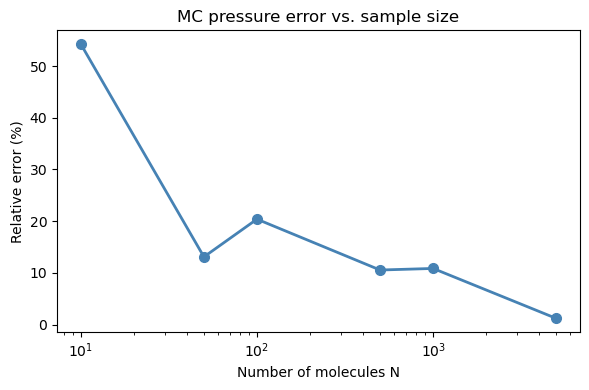

N =    10:  relative error = 54.25%
N =    50:  relative error = 13.11%
N =   100:  relative error = 20.40%
N =   500:  relative error = 10.56%
N =  1000:  relative error = 10.87%
N =  5000:  relative error = 1.21%


In [30]:
N_values = [10, 50, 100, 500, 1000, 5000]
errors   = []

for n in N_values:
    rng_i   = np.random.default_rng(seed=7)
    vx_i    = rng_i.normal(0, sigma_v, n)
    P_i     = (n / V) * m * np.mean(vx_i**2)
    P_ref   = (n * kB * T) / V          # exact pressure for this n
    errors.append(abs(P_i - P_ref) / P_ref * 100)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(N_values, errors, 'o-', color='steelblue', linewidth=2, markersize=7)
ax.set_xscale('log')
ax.set_xlabel('Number of molecules N')
ax.set_ylabel('Relative error (%)')
ax.set_title('MC pressure error vs. sample size')
plt.tight_layout()
plt.show()

for n, e in zip(N_values, errors):
    print(f"N = {n:5d}:  relative error = {e:.2f}%")

**Answer:**

As $N$ increases, $\langle v_x^2 \rangle$ converges to the true expectation $k_BT/m$ by the law of large numbers, so the MC pressure estimate approaches the exact value. The error decreases roughly as $1/\sqrt{N}$ — doubling the number of molecules reduces the error by about a factor of $\sqrt{2}$ — which is the characteristic convergence rate of any Monte Carlo average.

---

**Point Distribution:**

| Problem | Sub-parts | Total |
|---------|-----------|-------|
| Problem 1 — Descriptive Statistics | a) 5 + b) 5 + c) 10 + d) 10 | **30 pts** |
| Problem 2 — Random Sampling | a) 5 + b) 10 + c) 10 | **25 pts** |
| Problem 3 — Monte Carlo: Purity | a) 5 + b) 15 + c) 10 + d) 10 | **40 pts** |
| Bonus — Atomistic MC | a) 5 + b) 8 + c) 7 | **20 pts** |
| **Total (without bonus)** | | **95 pts** |
| **Total (with bonus)** | | **115 pts** |

Good luck!